<a href="https://colab.research.google.com/github/epythonlab2/AI_4_health/blob/main/module_2_unsupervised_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<header style="font-family: 'Inter', sans-serif; background: #ffffff; padding: 16px; border-radius: 8px; border: 1px solid #e1e4e8; display: flex; align-items: center; gap: 12px; box-shadow: 0 2px 8px rgba(0,0,0,0.05); margin-bottom: 10px;">
    <div style="width: 4px; height: 35px; background: linear-gradient(to bottom, #4e73df, #1cc88a); border-radius: 2px;"></div>
    <h1 style="color: #1a1a1a; margin: 0; font-size: 20px; font-weight: 700; border: none;">Module 2: Machine Learning and Statistics</h1>
</header>

<div style="font-family: 'Inter', sans-serif; max-width: 900px; margin: 15px 0; padding: 20px; border-radius: 10px; background: #f1f4ff; border: 1px solid #dbe3ff; display: flex; align-items: center; justify-content: space-between; gap: 15px;">
    <div style="flex: 1;">
        <h2 style="margin: 0; color: #2e59d9; font-size: 18px; font-weight: 700; border: none;">Chapter 3: Unsupervised Learning & Feature Engineering</h2>
        <span style="display: inline-block; margin-top: 8px; background: #ffffff; padding: 4px 12px; border-radius: 6px; color: #4e73df; font-weight: 800; font-size: 11px; border: 1px solid #dbe3ff; text-transform: uppercase;">12 Hours</span>
    </div>

   <a href="https://linkedin.com/in/dejenet" target="_blank" style="background-color: #0077b5; color: white; padding: 10px 20px; border-radius: 8px; text-decoration: none; font-size: 14px; font-weight: 700; white-space: nowrap;">
        Connect on LinkedIn
    </a>
</div>

**1. Big Picture: Supervised vs Unsupervised Learning**

####**1.1 What Problem Are We Solving?**

In the real world, "labels" (the answers) are expensive. They require human experts, time, and money. Unsupervised learning solves the **Cold Start Problem**: understanding your data before you have a target variable.

- **Customer Segmentation:** Grouping users by behavior (e.g., "Big Spenders" vs. "Window Shoppers") to tailor marketing.

- **Fraud Pattern Discovery:** You don't know what the next fraud looks like, but you can see what looks different from the norm.

- **Feature Discovery:** Using algorithms like PCA to compress 100 messy variables into 5 clean, highly informative ones.

####**1.2 Supervised vs Unsupervised(Conceptual)**

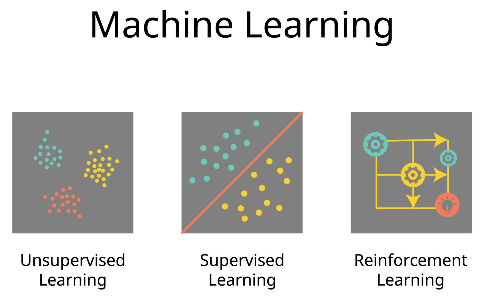

<table border="1" style="width:100%; border-collapse: collapse; text-align: left;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="padding: 12px;">Feature</th>
            <th style="padding: 12px;">Supervised Learning</th>
            <th style="padding: 12px;">Unsupervised Learning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px;"><strong>Input Data</strong></td>
            <td style="padding: 10px;">Features + Labels (<code>X and y</code>)</td>
            <td style="padding: 10px;">Features only (<code>X</code>)</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>Goal</strong></td>
            <td style="padding: 10px;">Predict a specific target</td>
            <td style="padding: 10px;">Find hidden patterns/structure</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>Feedback</strong></td>
            <td style="padding: 10px;">Direct (Loss functions / Accuracy)</td>
            <td style="padding: 10px;">Indirect (Cluster density / Variance)</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>Analogy</strong></td>
            <td style="padding: 10px;">A student with a textbook and an answer key.</td>
            <td style="padding: 10px;">A student exploring a museum without a tour guide.</td>
        </tr>
    </tbody>
</table>

####**1.3 Where Unsupervised Fits in ML Pipelines**

**1. Pre-processing: Feature Discovery & Engineering**

Before feeding data into a supervised model, unsupervised techniques are used to clean and simplify the input.

- **Dimensionality Reduction:** Using algorithms like **PCA** to merge 50 correlated variables into 5 "principal" ones. This prevents the "curse of dimensionality" and speeds up training.

- **Grouping Features:** Identifying which features behave similarly to create more meaningful aggregate variables.

**2. Standalone Analysis (Exploratory Data Analysis)**

Sometimes, the goal isn't to predict the future, but to understand the present.

- **Market Basket Analysis:** Figuring out that people who buy diapers also tend to buy beer.

- **Persona Creation:** Grouping a database of 1 million users into 4 distinct personas based on usage habits.

**3. Production Systems: Monitoring & Drift Detection**

Once a supervised model is deployed, unsupervised learning acts as a "security guard."

- **Data Drift:** An unsupervised model monitors the incoming live data. If the distribution of that data shifts significantly from the training data, it triggers an alert.

- **Outlier Detection:** Identifying "novelty" in data—like a sudden spike in traffic from a specific region—that the supervised model isn't trained to handle.

####**1.4 Hands-on: Transaction Dataset Exploration**

When you load a dataset (like a CSV of Customer Spending), you initially ignore any **"Label"** columns. Your goal is to look at the raw features ($X$) and find the "skeleton" of the data.

Download [Customer Spending Dataset](https://www.kaggle.com/datasets/goyaladi/customer-spending-dataset) from Kaggle

In [ ]:
from google.colab import files
import os

# 1. Upload the kaggle.json file you just downloaded
files.upload()

# 2. Set up the Kaggle directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download and unzip the dataset
!kaggle datasets download -d goyaladi/customer-spending-dataset
!unzip customer-spending-dataset.zip

# 4. Load the data
import pandas as pd
df = pd.read_csv('customer_data.csv', encoding='ISO-8859-1')

Saving kaggle.json to kaggle (10).json
Dataset URL: https://www.kaggle.com/datasets/goyaladi/customer-spending-dataset
License(s): CC0-1.0
  0% 0.00/23.3k [00:00<?, ?B/s]
100% 23.3k/23.3k [00:00<00:00, 81.9MB/s]
Archive:  customer-spending-dataset.zip
  inflating: customer_data.csv       


In [ ]:
# Explore the data
df.head()

,name,age,gender,education,income,country,purchase_frequency,spending
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780


At this stage, you’re just asking:
What does one row represent?

Usually the answer is: **one customer over a time period or one transaction event**.

**Explore columns without labels (no explanations yet)**

Before defining anything, inspect structure and types.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                1000 non-null   object 
 1   age                 1000 non-null   int64  
 2   gender              1000 non-null   object 
 3   education           1000 non-null   object 
 4   income              1000 non-null   int64  
 5   country             1000 non-null   object 
 6   purchase_frequency  1000 non-null   float64
 7   spending            1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


**Key things to notice:**

- **Number of rows** → how many customers or events?

- **Data types** → numeric vs categorical

- **Missing values** → Where might gaps exist?

In [ ]:
# Understand the features(X)
df.columns

Index(['name', 'age', 'gender', 'education', 'income', 'country',
       'purchase_frequency', 'spending'],
      dtype='object')

<table border="1" style="width:100%; border-collapse: collapse; text-align: left; font-family: sans-serif;">
    <thead>
        <tr style="background-color: #e0e0e0;">
            <th style="padding: 12px;">Column Name</th>
            <th style="padding: 12px;">Data Type</th>
            <th style="padding: 12px;">Action for Clustering</th>
            <th style="padding: 12px;">Reasoning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px;"><strong>name</strong></td>
            <td style="padding: 10px;">Unique String</td>
            <td style="padding: 10px; color: #d9534f;"><strong>Drop (Selection)</strong></td>
            <td style="padding: 10px;">Unique identifiers have no mathematical pattern.</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>age, income, spending</strong></td>
            <td style="padding: 10px;">Numerical</td>
            <td style="padding: 10px; color: #5bc0de;"><strong>Scale (StandardScaler)</strong></td>
            <td style="padding: 10px;">Ensures large income numbers don't drown out age.</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>gender, country</strong></td>
            <td style="padding: 10px;">Nominal Categorical</td>
            <td style="padding: 10px; color: #f0ad4e;"><strong>One-Hot Encoding</strong></td>
            <td style="padding: 10px;">Creates binary 1/0 columns (e.g., is_UK, is_USA).</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>education</strong></td>
            <td style="padding: 10px;">Ordinal Categorical</td>
            <td style="padding: 10px; color: #5cb85c;"><strong>Label/Ordinal Encoding</strong></td>
            <td style="padding: 10px;">Preserves the rank (e.g., High School &lt; Masters).</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>purchase_frequency</strong></td>
            <td style="padding: 10px;">Numerical / Ratio</td>
            <td style="padding: 10px; color: #5bc0de;"><strong>Scale</strong></td>
            <td style="padding: 10px;">Standardizes the behavior "signal" for distance.</td>
        </tr>
    </tbody>
</table>

In [ ]:
# Check the rows and columns
df.shape

(1000, 8)

In [ ]:
# Check missing values
df.isna().sum()

,0
name,0
age,0
gender,0
education,0
income,0
country,0
purchase_frequency,0
spending,0


**1. Ask the key question:** “What patterns might exist here?”

Without defining anything, you can already explore:

**Demographic patterns**

- Does spending change with age?

- Does income scale linearly with spending?

**Behavioral segmentation**

- High purchase frequency + low spending?

- Low frequency + high spending?

**Group differences**

- Spending differences by education level

- Purchase frequency across countries

**Outliers**

- Very high income, very low spending

- Very young age with unusually high spending

**2. What this dataset is naturally good for**

Even unlabeled, this is perfect for:

- Customer segmentation

- Behavioral profiling

- Marketing analysis

- Clustering

- Simple regression exploration

**3. Mental summary (important)**

Without knowing the story, you can still say:

> This dataset describes people and how they spend, combining demographics with purchasing behavior.

That’s enough to start real analysis.

### **2. Introduction to Clustering**



#### **2.1 What Is Clustering Really Doing?**

At its core, clustering is about **finding patterns in** **similarity**.

The algorithm looks at your data and asks a simple question:**Which observations behave alike?**

It doesn’t care about labels, outcomes, or correctness. It only measures distance, similarity, or density and then groups points that “feel close” to each other based on those rules.

**1. Grouping Similar Behaviors**

Clustering groups data points that show **similar behavior**, not identical values.

For example:

- Customers with similar spending habits

- Transactions with similar amounts and timing

- Patients with similar health measurements

Two points end up in the same cluster because their overall patterns match, even if no single feature is exactly the same.

This is why clustering is powerful in exploratory analysis. It helps you discover structure you didn’t explicitly define.

**2. No “Right or Wrong” Answers**

Unlike supervised learning, clustering has:

- No ground truth labels

- No correct output to compare against

Different algorithms can produce different clusters from the same data, and **that’s normal**.

**K-Means, DBSCAN, and Hierarchical Clustering** are not competing to find the “true” clusters. They are answering **different questions** about the data.

So instead of asking:

> Is this clustering correct?

The better question is:

> Is this clustering useful for my problem?




**3. Clusters Are Hypotheses, Not Truths**

A cluster is not a fact. It’s a **hypothesis**.

When an algorithm creates a cluster, it’s essentially saying:

> These points might belong together based on the rules I used.

It’s up to you to:

- Interpret the clusters

- Validate them with domain knowledge

- Decide whether they make sense in context

In practice, clusters often lead to **questions**, not answers:

- Why do these customers behave differently?

- What separates this group from the others?

- Should this cluster be treated differently in a business or policy decision?

**Key takeaway:**
Clustering doesn’t discover truth. It proposes structure.

Your job is to judge whether that structure is meaningful, useful, and defensible in the real world.

####**2.2 Common Clustering Use Cases in Finance**

**Clustering** is widely used in finance because many important patterns are **not** **labeled in advance**. We often don’t know who is risky, loyal, or abnormal until we explore the data.

**1. Spending Behavior Segmentation**

Banks and fintech companies cluster customers based on how they spend money, not who they are.

Typical features include:

- Transaction amounts

- Frequency of purchases

- Merchant categories

- Time and location patterns

This helps answer questions like:

- Who are high-value customers?

- Who spends steadily vs irregularly?

- Which users are price-sensitive or impulsive?

These segments drive personalized offers, credit limits, and product design.

**2. Risk Profiling**

Clustering is often used as a **pre-risk step**, before any predictive model.

By clustering customers or transactions, institutions can identify:

- Low-risk, stable behavior patterns

- Medium-risk groups with emerging volatility

- Unusual or rare behavior that deserves closer monitoring

Importantly, clustering does not label someone as “**fraudulent**” or “**default-prone**.”

It flags **behavioral similarity**, which analysts then investigate further.

**3. Customer Lifecycle Analysis**

Customers change over time. Clustering helps track where they are in **their financial journey**.

Common lifecycle clusters include:

- New users learning the platform

- Active and growing customers

- Stable, mature customers

- Dormant or declining users

By clustering behavior across time windows, companies can:

- Detect early churn signals

- Design retention strategies

- Target re-engagement campaigns

**Key takeway:** In finance, clustering is not about prediction. It’s about **understanding structure in behavior** so better decisions can follow.

###**3. Distance Metrics (High-Level)**

To understand how clustering works, you have to understand **distance**. If clustering is about "grouping similar things," distance is the ruler we use to measure that "**similarity**."

In a 2D space, distance is **intuitive**. In high-dimensional data (like a customer profile with 50 different variables), distance becomes the **mathematical language of relationshi**p.

####**3.1 Euclidean Distance:** **"The Bird’s Flight"**

This is the most common metric. It is the straight-line distance between two points. It’s best when your data is dense and continuous (like height, weight, or salary). In a 2D plane, the distance $d$ between points $(x_1, y_1)$ and $(x_2, y_2)$ is:$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

**Pros:** Intuitive and works for most physical-world problems.

**Cons:** Very sensitive to outliers and scale (if one variable is in "meters" and another in "kilometers," the kilometers will dominate the calculation)

**Example:** Try this thought experiment:

1. Point $A: (0, 0) -> (x_1, y_1)$

2. Point $B: (3, 4) -> (x_2, y_2)$

Euclidean Distance: $\sqrt{3^2 + 4^2} = 5$ units.

**Hands-on:** Search for **Mall Customer Segmentation Data** on Kaggle

In [ ]:
import kagglehub
path = kagglehub.dataset_download("polarbearwyy/mall-customer-segmentation-data")

Using Colab cache for faster access to the 'mall-customer-segmentation-data' dataset.


In [11]:
import os

# List files in the downloaded path
print(os.listdir(path))
# Construct the full file path
# This dynamically joins the folder path with the specific CSV name
csv_path = os.path.join(path, "Mall_Customers.csv")

['Mall_Customers.csv']


In [12]:
import pandas as pd
# Read the data
df = pd.read_csv(csv_path)

# View the first few rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
# Rename columns
df.columns = ['customer_id', 'age', 'gender', 'income', 'spending_score']

In [ ]:
# 1. Select the best columns for Euclidean distance
features = ['income', 'spending_score']
X = df[features]

In [18]:
from sklearn.preprocessing import StandardScaler
# 2. SCALE THE DATA (Crucial for Euclidean!)
# This makes $50,000 income comparable to a 75/100 spending score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
from sklearn.cluster import KMeans

# 3. Run K-Means (which uses Euclidean distance by default)
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,customer_id,age,gender,income,spending_score,cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
import matplotlib.pyplot as plt
# 4. Visualize the "Seams"
plt.scatter(df['income'], df['spending_score'], c=df['cluster'], cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Euclidean Distance at Work')
plt.show()